In [1]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import os
import gc
from pathlib import Path
from define_data_and_variables import pt_config, data, hash_configs, version
import json


In [2]:
base_dir = Path.cwd()
print(base_dir)

base_path = base_dir / ".." / ".." / ".." / ".." / "data"
print(data["dn"].lower())
data_name = rf"$A_{{{data["dn"][:3]}}}$"
ylim_max = 0.4
bin_range = (1660, 1730)
true_sample = np.load(base_path / data["dn"] / version / "true_sample.npy")
int_version = int(version)
# if data["dn"].lower() == "dayu19a":
#     bin_range = (1676, 1727)
#     data_color = "red"
#     data_name = r"$A_1$"
#     ylim_max = 0.4
# elif data["dn"].lower() == "dayu19b":
#     true_sample = np.load(base_path / "inputdata_260219B" / "true_sample.npy")
#     bin_range = (1660, 1720)
#     data_color = "orange"
#     data_name = r"$A_2$"
#     ylim_max = 0.15
# if data["dn"].lower() == "dayu19c":
#     true_sample = np.load(base_path / "inputdata_260219C" / "true_sample.npy")
#     bin_range = (1680, 1720)
#     data_color = "yellow"
#     data_name = r"$A_3$"
#     ylim_max = 0.25
# print(true_sample)
true_ages = np.hstack((data["th"], data["th"] - np.cumsum(true_sample) * data["dc"]))
print(true_ages)

c:\Users\hanna\Desktop\PhD\Bacon\python\src\age_depth_models\age_depth_model_PT_normal
dayu_d18o
[1983.         1972.03797804 1964.0084901  1957.45143296 1943.65350686
 1936.49271068 1919.02919483 1911.27560962 1904.44651724 1895.5514633
 1886.87604737 1877.98966935 1872.50393577 1839.74377844 1835.87629141
 1821.60904932 1799.9853559  1789.18711573 1785.45336621 1768.37225658
 1756.39326337 1749.6579898  1737.29470654 1727.24134845 1689.01246499
 1678.87816094 1663.56561226 1660.42302651 1656.62954639 1632.65628473
 1625.47068363 1612.83447667 1599.31705211 1591.57389739 1588.17411702
 1575.17236355 1564.86473177 1552.92836121 1547.90101184 1536.65988649
 1473.45093356 1459.40005047 1448.42698216 1435.50324579 1359.40828283
 1349.43870137 1325.55951354 1297.80466631 1284.90722555 1272.3007369
 1239.11920758]


In [3]:
base_dir = Path.cwd()
# adam_config_ee = adam_config
# adam_config_ee["mi"] = 10000
# adam_hash_ee = hash_configs(adam_config_ee, data)

# adam_dir = base_dir / f"output/{data["dn"]}/{adam_hash}"
# adam_dir_ee = base_dir / f"output/{data['dn']}/{adam_hash_ee}"

# starting_points = np.load(adam_dir / "adam_samples.npy")
# energies = np.load(adam_dir / "adam_energies.npy")

# indices = np.argsort(energies)
# sp = starting_points[indices][:pt_config["nt"]]
sp_dir = base_dir / f"output/{data['dn']}/{version}"
np.random.seed(pt_config['hmcc']['sd'])
sp = np.random.lognormal(mean = data["pm"], sigma = data["ps"], size = (pt_config["nt"], data["N"]))
pt_config["hmcc"]["sp"] = np.ascontiguousarray(sp)

pt_hash = hash_configs(pt_config, data)
output_dir = sp_dir / f"{pt_hash}"

hmc_config = pt_config["hmcc"]

In [4]:
colors = plt.cm.viridis(np.linspace(0, 1, pt_config["nt"]))

[[ 0  1  1 ...  5  5  5]
 [ 1  0  3 ...  3  3 15]
 [ 2  3  0 ... 15 15  3]
 ...
 [17 17 17 ... 12  9  9]
 [18 18 18 ... 18 16 16]
 [19 19 19 ... 16 18 18]]
(20, 100001)
[[ 0  1  1 ...  5  5  5]
 [ 1  0  3 ...  3  3 15]
 [ 2  3  0 ... 15 15  3]
 ...
 [17 17 17 ... 12  9  9]
 [18 18 18 ... 18 16 16]
 [19 19 19 ... 16 18 18]]


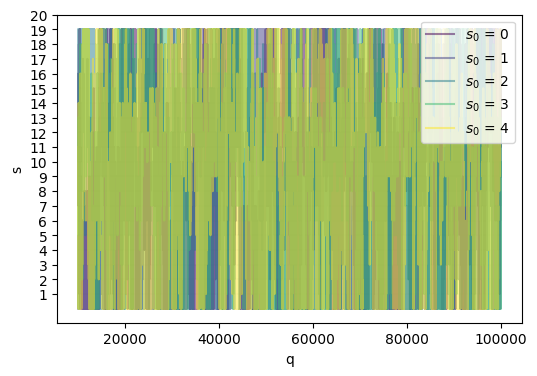

In [5]:
import matplotlib as mpl

num_starts = 5
temp_indices = np.load(output_dir / "temp_indices.npy")
norm = mpl.colors.Normalize(vmin=min(pt_config['bs'][0:num_starts]), vmax=max(pt_config['bs'][0:num_starts]))
cmap = plt.cm.viridis
# temp_indices = (temp_indices == 19).argmax(axis=0)
print(temp_indices)
print(np.shape(temp_indices))
plt.figure(figsize=(6, 4))
xmin = 10000
xmax = 100000
# for i in range(len(temp_indices)):
plt.hlines(np.linspace(0, pt_config["nt"] - 1, pt_config["nt"]), linestyle = '--', color = "grey", linewidth = 0.1,  xmin = xmin, xmax = xmax)
for i in range(0, num_starts):
    temp_indices_i = (temp_indices == i).argmax(axis=0)
    plt.plot(np.arange(xmin, xmax, 1), temp_indices_i[xmin:xmax], label = r"$s_0$" + f" = {i}", color = cmap(norm(pt_config['bs'][i])), alpha = 0.5)  
print(temp_indices)
plt.yticks(np.linspace(1, pt_config["nt"], pt_config["nt"]))
plt.ylabel("s")
plt.xlabel("q")
plt.legend(loc = "upper right")
plt.savefig(f"{output_dir}/index_evolution.jpg")
plt.show()


In [6]:
cutout = 1000
backwards = False
round_trip = 0
num_temps = len(temp_indices)
num_samples = len(temp_indices[0, cutout:])
for chain in range(num_temps):
    for col in range(num_samples):
        if temp_indices[0, col] == chain and backwards:
            round_trip+=1
            backwards = False
        if temp_indices[-1, col] == chain:
            backwards = True
print(round_trip / (num_samples * num_temps))


0.00048585367824567426


In [7]:
samples = np.load(output_dir / "samples.npy", mmap_mode='r')[:, cutout:, :]

In [8]:
energy_values = np.load(output_dir / "energy.npy", mmap_mode='r')[:, cutout:]
min_energies = [np.min(energy_values, axis = 1)[i] for i in range(pt_config["nt"])]
min_energy_samples = [samples[i, np.argmin(energy_values, axis = 1)[i], :] for i in range(pt_config["nt"])]
closest_to_true_samples = [samples[i, np.argmin(np.linalg.norm(samples[i, :, :] - true_sample, axis = 1)), :] for i in range(pt_config["nt"])]
print(min_energies)

[np.float64(79.7937939302923), np.float64(82.16636774173125), np.float64(84.25736423201636), np.float64(87.13033473024745), np.float64(86.33424875168022), np.float64(92.51597414831048), np.float64(97.3276715479635), np.float64(100.42409569654218), np.float64(103.78305730790605), np.float64(109.44841014291777), np.float64(113.48809215283781), np.float64(121.04117716378249), np.float64(129.174443492533), np.float64(133.40754345212585), np.float64(142.60620789522187), np.float64(157.3482275525146), np.float64(169.77752858628355), np.float64(185.6771996280238), np.float64(201.50812921648492), np.float64(225.94892374671747)]


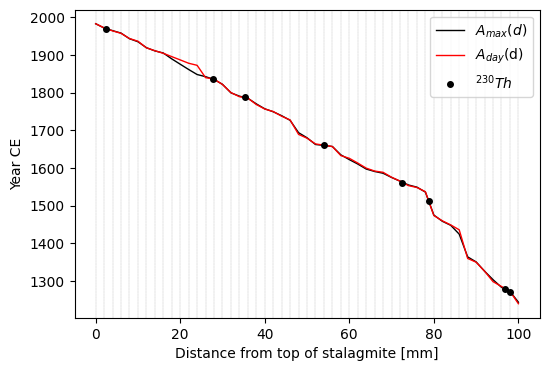

In [9]:
chain = -1
fig, ax = plt.subplots(figsize=(6, 4))
# plt.plot(data["cs"], data["th"] - data["dc"]*np.hstack(([chain], np.cumsum(closest_to_true_samples[chain]))), color = "black", alpha = 1, linewidth = 0.5, label = r"$A_{close}(d)$")
plt.plot(data["cs"], data["th"] - data["dc"]*np.hstack(([0], np.cumsum(min_energy_samples[chain]))), color = "black", alpha = 1, linewidth = 1, label = r"$A_{max}(d)$")
ax.plot(data["cs"], true_ages, color = "red", linewidth=1, alpha = 1, label = data_name + "(d)")
for i, c in enumerate(data["cs"]):
    ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = r"$^{230}Th$")
plt.xlabel("Distance from top of stalagmite [mm]")
plt.ylabel("Year CE")
plt.legend()
plt.savefig(f"{output_dir}/close_and_max_prob_sol.jpg")
plt.show()

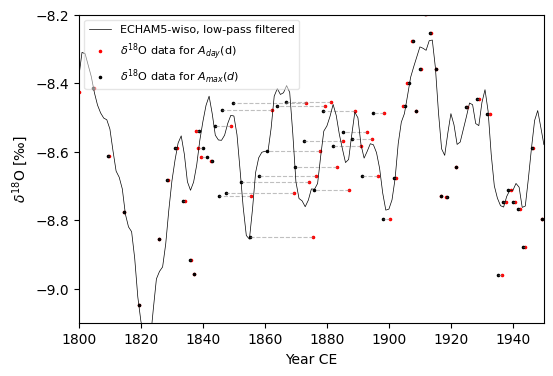

In [22]:
fig, ax = plt.subplots(figsize=(6, 4))
# 1. Define your two sets of X coordinates
x_data = data["d18ota"]
x_model = np.interp(
    data["d18od"], 
    data["cs"], 
    data["th"] - data["dc"] * np.hstack(([chain], np.cumsum(min_energy_samples[chain])))
)
y_vals = data["d18o"] # The Y values are the same for both, right?
ax.plot(data["d18ort"], data["d18or"], color = "black", linewidth = 0.5, label = "ECHAM5-wiso, low-pass filtered")
ax.scatter(
    x_data, 
    y_vals, 
    color="red", 
    marker = ".", 
    s = 10,
    label=fr"$\delta^{{{18}}}$O data for {data_name}(d)"
)

# ax.scatter(
#     np.interp(data["d18od"], data["cs"], data["th"] - data["dc"]*np.hstack(([chain], np.cumsum(closest_to_true_samples[chain])))), 
#     data["d18o"], 
#     # yerr=data["d18os"],       # The error values (can be a constant or array)
#     color="black", 
#     marker="*", 
#     s=10,                # Makes the stars smaller (default is 6)
#     # linestyle="None",            # Ensures no lines connect the points
#     # capsize=2,                   # Optional: adds "caps" to the ends of error bars
#     # elinewidth=0.5,              # Optional: makes the error bar lines thinner
#     label=r"Data regenerated from $A_{close}(d)$"
# )

ax.scatter(
    x_model, 
    y_vals, 
    # yerr=data["d18os"],       # The error values (can be a constant or array)
    color="black", 
    marker=".", 
    s=10,                # Makes the stars smaller (default is 6)
    # linestyle="None",            # Ensures no lines connect the points
    # capsize=2,                   # Optional: adds "caps" to the ends of error bars
    # elinewidth=0.5,              # Optional: makes the error bar lines thinner
    label=r"$\delta^{18}$O data for $A_{max}(d)$"
)

# 2. Loop through and draw a line between each corresponding pair
for i in range(len(y_vals)):
    ax.plot(
        [x_data[i], x_model[i]], # X-start to X-end
        [y_vals[i], y_vals[i]], # Y-start to Y-end (stays on same horizontal line)
        color="grey", 
        linestyle="--", 
        linewidth=0.8,
        alpha=0.5,           # Makes lines subtle so they don't crowd the plot
        zorder=1             # Puts the lines behind the scatter stars
    )
# ax.plot(np.interp(data["d18od"], data["cs"], true_ages), data["d18o"], color = "purple", linestyle = '--', label = "true data")
# ax.scatter(np.interp(data["d18od"], data["cs"], data["th"] - data["dc"]*np.hstack(([chain], np.cumsum(min_energy_samples[chain])))), data["d18o"], color = "red", marker = 'o', markersidth = 0.1, label = "most likely data")
plt.xlim((1800, 1950))
plt.ylim((-9.1, -8.2))
plt.ylabel("$\\delta^{18}$O [‰]")
plt.xlabel("Year CE")
plt.legend(loc = "upper left", framealpha=0.5, prop={'size': 8})
plt.savefig(f"{output_dir}/data_compare.jpg")
plt.show()


In [11]:
import arviz as az
# for i in range(len(samples[-1,0,:])):    
#     print(f"ess x[{i}]: {az.ess(samples[-1, :, i], method="bulk")}")

ess_array = np.array([az.ess(samples[-1, :, i], method = "bulk") for i in range(len(samples[-1, 0, :]))])
print(ess_array)
min_ess = np.min(ess_array)
print(min_ess)

[ 54437.63292673  90122.98970923  70327.80375941  31752.70973727
  47644.01838626  48013.01712641  37168.06405412  34036.6898894
  26678.07582761   3821.14537638   2662.3478387    9121.74615901
   2791.75590293  17195.58112244  37394.46407346  49770.79684982
  51452.87573887  31566.92404703   3444.92417794   3891.54083529
   3454.94085524  24103.29264022   9999.0593826    2938.51422626
  21971.48828317  23307.56359972  27821.86000899  15803.25084958
  17065.84736965  36837.14810497  42594.27014403  43033.32365174
  39716.61004942  38086.81870074  59750.09441128 101062.90264305
  73410.42323196  31808.49178856  34704.5400976   30430.53756692
  19685.86238169  16387.80591026   1505.11438708   1485.91908105
   4263.09876402  53594.70074384  69288.98580877  70890.5274579
  61001.64944829  23862.88425051]
1485.9190810503464


In [12]:
print(output_dir)
print(min_ess)

c:\Users\hanna\Desktop\PhD\Bacon\python\src\age_depth_models\age_depth_model_PT_normal\output\dayu_d18o\2\9e0652caf8
1485.9190810503464


In [13]:
# short_samples = samples[:, 500::10, :]
# cumulative_sums = np.cumsum(short_samples, axis=2) * data["dc"]
# zeros = np.zeros((*short_samples.shape[:2], 1))
# age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

# model_ages = data["th"] - age_offsets

# # Age depth trace plot
# fig, ax = plt.subplots(figsize=(6, 4))
# num_samples = len(short_samples[0,:,0])
# # for i in range(pt_config["nt"]):
# for j in range(num_samples):
#     ax.plot(
#         data["cs"],
#         model_ages[-1, j, :],
#         color=colors[0],
#         alpha=0.3,
#         linewidth=0.1,
#     )

# ax.set_xlim(0, np.max(data["cs"]))
# ax.set_ylim(1200, 2000)
# plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
# plt.plot(data["d18od"], data["d18ota"], color = 'k', linewidth=0.5)
# plt.xlabel("Depth")
# plt.ylabel("Age")
# plt.tight_layout()
# plt.savefig(f"{output_dir}/age_depth_samples.jpg")
# plt.show()

In [14]:
# short_samples = samples[:, 500::10, :]
# cumulative_sums = np.cumsum(short_samples, axis=2) * data["dc"]
# zeros = np.zeros((*short_samples.shape[:2], 1))
# age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

# model_ages = data["th"] - age_offsets

# # Age depth trace plot
# fig, ax = plt.subplots(figsize=(6, 4))
# num_samples = len(short_samples[-1,:,0])
# # for i in range(pt_config["nt"]):
# for j in range(num_samples):
#     ax.plot(
#         data["cs"],
#         model_ages[0, j, :],
#         color=colors[0],
#         alpha=0.3,
#         linewidth=0.1,
#     )

# ax.set_xlim(0, np.max(data["cs"]))
# ax.set_ylim(1200, 2000)
# plt.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4)
# plt.plot(data["d18od"], data["d18ota"], color = 'k', linewidth=0.5)
# plt.xlabel("Depth")
# plt.ylabel("Age")
# plt.tight_layout()
# plt.savefig(f"{output_dir}/age_depth_highT_samples.jpg")
# plt.show()

In [15]:
# short_samples = samples[-1, ::int(len(samples[-1, :, 0]) / min_ess), :]

In [23]:
index = 12
interesting_depth = index * data["dc"]

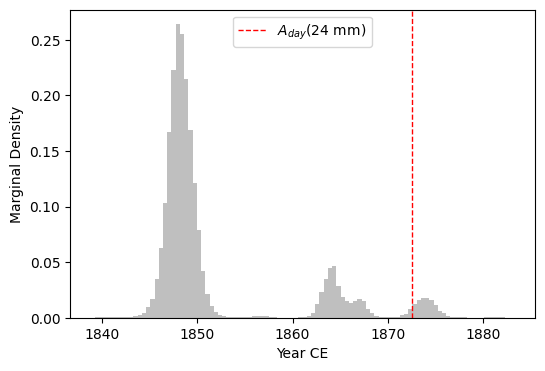

In [24]:
CV_values = data["th"] - data["dc"] * np.sum(samples[-1, :, :index], axis = 1)
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(CV_values, bins = 100, color = "grey", alpha = 0.5, density = True)
ax.set_xlabel("Year CE")
ax.set_ylabel("Marginal Density")
ax.axvline(x=true_ages[index], color="red", linestyle='--', linewidth = 1, label = data_name + f"({int(interesting_depth)} mm)")
plt.legend()
plt.savefig(f"{output_dir}/samples_along_depth_{interesting_depth}.jpg")
plt.show()

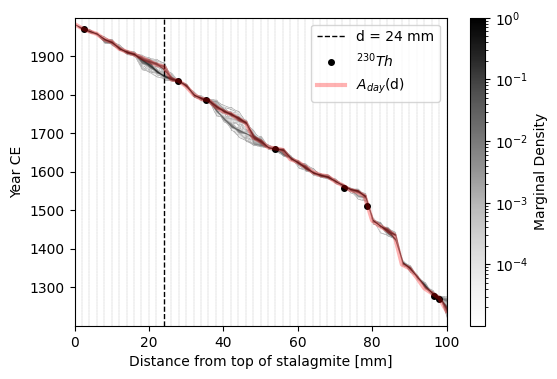

In [25]:
from matplotlib import colors

X = samples[-1, :, :].T
D, N = X.shape

# Depth grid (0:2:2*D)'

age = np.vstack([
    np.ones((1, N)) * data["th"],
    data["th"] - data["dc"] * np.cumsum(X, axis=0)
])

# age_mean = np.mean(age, axis = 1)
norm_age = age #- true_age[:, None]

# Time bins
dt = 1
t_edges = np.arange(1200, 2000 + dt, dt)
t = t_edges[1:] - dt / 2
T = t.size

# Depth interpolation grid
dz = 0.1
z = np.arange(0, data["dc"] * D + dz, dz)
Z = z.size

# Allocate result
C = np.full((Z, T), np.nan)
A = np.array([
    np.interp(z, data["cs"], norm_age[:, j])
    for j in range(N)
]).T

for i in range(Z):
    C[i, :], _ = np.histogram(A[i, :], bins=t_edges, density = True)

fig, ax = plt.subplots(figsize=(6, 4))
plt.set_cmap(plt.cm.Greys)
for i, c in enumerate(data["cs"]):
    if i ==index: 
        ax.axvline(x=c, color='k', linestyle='--', linewidth = 1, label = f"d = {int(interesting_depth)} mm")
    else:
        ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = r"$^{230}Th$")
ax.plot(data["cs"], true_ages, color = "red", linewidth=3, alpha = 0.3, label = data_name + "(d)")
im = ax.imshow(
    C.T,
    extent=[z[0], z[-1], t[0], t[-1]],
    origin='lower',
    aspect='auto',
    # vmin=0,
    # vmax=0.01 * N,
    norm=colors.LogNorm()
)

plt.legend(loc = "upper right")
cbar = plt.colorbar(im)
cbar.set_label("Marginal Density")
plt.xlabel("Distance from top of stalagmite [mm]")
plt.ylabel("Year CE")
plt.savefig(f"{output_dir}/resampled_no_mean.jpg")
plt.show()

# del A, C
# gc.collect()


In [26]:
# from matplotlib import colors

# chain = 0
# X = samples[chain, cutout:, :].T
# D, N = X.shape

# # Depth grid (0:2:2*D)'
# depth = np.arange(0, 2 * D + 1, 2)

# age = np.vstack([
#     np.ones((1, N)) * data["th"],
#     data["th"] - data["dc"] * np.cumsum(X, axis=0)
# ])

# # age_mean = np.mean(age, axis = 1)
# norm_age = age #- true_age[:, None]

# # Time bins
# dt = 1
# t_edges = np.arange(1200, 2000 + dt, dt)
# t = t_edges[1:] - dt / 2
# T = t.size

# # Depth interpolation grid
# dz = 0.1
# z = np.arange(0, 2 * D + dz, dz)
# Z = z.size

# # Allocate result
# C = np.full((Z, T), np.nan)
# A = np.array([
#     np.interp(z, depth, norm_age[:, j])
#     for j in range(N)
# ]).T

# for i in range(Z):
#     C[i, :], _ = np.histogram(A[i, :], bins=t_edges)

# fig, ax = plt.subplots(figsize=(6, 4))
# plt.set_cmap(plt.cm.Greys)
# for i, c in enumerate(data["cs"]):
#     # if i ==25: 
#     #     ax.axvline(x=c, color='k', linestyle='--', linewidth = 1)
#     # else:
#     ax.axvline(x=c, color='k', linestyle='--', linewidth = 0.1)

# ax.plot(data["c14d"], np.squeeze(data["c14"]), "ko", markersize=4, label = r"$^{230}Th$")
# ax.plot(data["d18od"], data["d18ota"], color = 'orange', linewidth=3, alpha = 0.2, label = r"$A_2(d)$")

# im = ax.imshow(
#     C.T,
#     extent=[z[0], z[-1], t[0], t[-1]],
#     origin='lower',
#     aspect='auto',
#     # vmin=0,
#     # vmax=0.01 * N,
#     norm=colors.LogNorm()
# )

# plt.legend(loc = "upper right")
# cbar = plt.colorbar(im)
# cbar.set_label("Counts")
# plt.xlabel("Distance from top of stalagmite [mm]")
# plt.ylabel("Year CE")
# plt.savefig(f"{output_dir}/resampled_no_mean_{chain}_highT.jpg")
# plt.show()


In [27]:
# d18o_energy_values = np.load(f"{output_dir}/d18o_energy.npy")